In [7]:
# Cell 1: Import Libraries
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
from PIL import Image

print("NumPy version:", np.__version__)
print("OpenCV version:", cv2.__version__)
print("All libraries imported successfully!")

NumPy version: 2.4.2
OpenCV version: 4.13.0
All libraries imported successfully!


In [8]:
# Cell 2: Load the Dataset
# Define paths
DATA_PATH = r"C:\Users\Paramu\guvi_face_segmentation\data"
NPY_FILE = os.path.join(DATA_PATH, "Part 1- Train data - images.npy")

# Load the .npy file
print("Loading dataset... (this may take 30-60 seconds due to file size)")
data = np.load(NPY_FILE, allow_pickle=True)

print("Dataset loaded successfully!")
print("Data type:", type(data))
print("Data shape:", data.shape)
print("Total samples:", len(data))

Loading dataset... (this may take 30-60 seconds due to file size)
Dataset loaded successfully!
Data type: <class 'numpy.ndarray'>
Data shape: (409, 2)
Total samples: 409


In [9]:
# Cell 3: Explore Data Structure
print("Exploring one sample...")
print("Type of data[0]:", type(data[0]))
print("Type of data[0][0]:", type(data[0][0]))
print("Type of data[0][1]:", type(data[0][1]))

# Check shape of first image and mask
img = data[0][0]
mask = data[0][1]

print("\nFirst image shape:", img.shape)
print("First mask shape:", mask.shape)
print("Image pixel range - Min:", img.min(), "Max:", img.max())
print("Mask pixel range - Min:", mask.min(), "Max:", mask.max())

Exploring one sample...
Type of data[0]: <class 'numpy.ndarray'>
Type of data[0][0]: <class 'numpy.ndarray'>
Type of data[0][1]: <class 'list'>

First image shape: (333, 650, 3)


AttributeError: 'list' object has no attribute 'shape'

In [ ]:
# Cell 4: Explore Data Structure (Fixed)
img = data[0][0]
mask = data[0][1]

# Convert mask to numpy array
mask = np.array(mask)

print("First image shape:", img.shape)
print("First mask shape:", mask.shape)
print("Image pixel range - Min:", img.min(), "Max:", img.max())
print("Mask pixel range - Min:", mask.min(), "Max:", mask.max())
print("\nTotal images in dataset:", len(data))
print("Image data type:", img.dtype)
print("Mask data type:", mask.dtype)

In [ ]:
# Cell 5: Deep inspect the data structure
print("=== Inspecting data[0] ===")
print("data[0] type:", type(data[0]))
print("data[0] length:", len(data[0]))

print("\n=== data[0][0] - the IMAGE ===")
print("Type:", type(data[0][0]))
print("Shape:", data[0][0].shape)

print("\n=== data[0][1] - the MASK ===")
print("Type:", type(data[0][1]))
print("Length:", len(data[0][1]))

# Check what's inside the mask
mask_raw = data[0][1]
print("\nFirst element of mask:", type(mask_raw[0]))
print("Second element of mask:", type(mask_raw[1]))

# Try to peek at contents
print("\nmask_raw[0]:", mask_raw[0] if not isinstance(mask_raw[0], np.ndarray) else f"array shape {mask_raw[0].shape}")
print("mask_raw[1]:", mask_raw[1] if not isinstance(mask_raw[1], np.ndarray) else f"array shape {mask_raw[1].shape}")

In [ ]:
# Cell 6: Convert polygon annotations to binary masks and visualize

def create_mask_from_polygons(annotation_list, img_height, img_width):
    """Convert polygon points to a binary mask image"""
    mask = np.zeros((img_height, img_width), dtype=np.uint8)
    for annotation in annotation_list:
        points = annotation['points']
        # Convert normalized coordinates to pixel coordinates
        pts = np.array([[int(p['x'] * img_width), int(p['y'] * img_height)] 
                        for p in points], dtype=np.int32)
        cv2.fillPoly(mask, [pts], 255)
    return mask

# Test with first sample
img = data[0][0]
annotations = data[0][1]
h, w = img.shape[:2]

mask = create_mask_from_polygons(annotations, h, w)

print("Image shape:", img.shape)
print("Generated mask shape:", mask.shape)
print("Unique mask values:", np.unique(mask))

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axes[0].set_title("Original Movie Scene")
axes[0].axis('off')

axes[1].imshow(mask, cmap='gray')
axes[1].set_title("Face Mask (generated)")
axes[1].axis('off')

# Overlay
overlay = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).copy()
overlay[mask > 0] = [255, 0, 0]
axes[2].imshow(overlay)
axes[2].set_title("Overlay (faces in red)")
axes[2].axis('off')

plt.tight_layout()
plt.show()
print("Visualization complete!")

In [ ]:
# Cell 7: Fix mask generation and explore more samples

def create_mask_from_polygons(annotation_list, img_height, img_width):
    mask = np.zeros((img_height, img_width), dtype=np.uint8)
    for annotation in annotation_list:
        points = annotation['points']
        pts = np.array([[int(p['x'] * img_width), int(p['y'] * img_height)] 
                        for p in points], dtype=np.int32)
        if len(pts) >= 3:
            cv2.fillPoly(mask, [pts], 255)
        else:
            # If only 2 points, draw a rectangle/ellipse around face area
            x_coords = [int(p['x'] * img_width) for p in points]
            y_coords = [int(p['y'] * img_height) for p in points]
            x1, y1 = min(x_coords), min(y_coords)
            x2, y2 = max(x_coords), max(y_coords)
            cx, cy = (x1+x2)//2, (y1+y2)//2
            rx, ry = max(abs(x2-x1)//2, 20), max(abs(y2-y1)//2, 30)
            cv2.ellipse(mask, (cx, cy), (rx, ry), 0, 0, 360, 255, -1)
    return mask

# Visualize 6 different samples
fig, axes = plt.subplots(6, 3, figsize=(15, 30))

for i in range(6):
    img = data[i][0]
    annotations = data[i][1]
    h, w = img.shape[:2]
    mask = create_mask_from_polygons(annotations, h, w)
    
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    overlay = img_rgb.copy()
    overlay[mask > 0] = [255, 0, 0]
    
    axes[i][0].imshow(img_rgb)
    axes[i][0].set_title(f"Sample {i+1}: Original")
    axes[i][0].axis('off')
    
    axes[i][1].imshow(mask, cmap='gray')
    axes[i][1].set_title(f"Sample {i+1}: Face Mask")
    axes[i][1].axis('off')
    
    axes[i][2].imshow(overlay)
    axes[i][2].set_title(f"Sample {i+1}: Overlay")
    axes[i][2].axis('off')

plt.tight_layout()
plt.show()
print("EDA visualization complete!")

In [ ]:
# Cell 8: Prepare full dataset - resize all images and masks to 256x256

IMG_SIZE = 256
images = []
masks = []

print("Processing all 409 samples...")
for i in range(len(data)):
    img = data[i][0]
    annotations = data[i][1]
    h, w = img.shape[:2]
    
    # Create mask from polygons
    mask = create_mask_from_polygons(annotations, h, w)
    
    # Resize both to 256x256
    img_resized = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    mask_resized = cv2.resize(mask, (IMG_SIZE, IMG_SIZE))
    
    # Normalize image to 0-1
    img_normalized = img_resized / 255.0
    
    # Binary mask: 0 or 1
    mask_binary = (mask_resized > 127).astype(np.float32)
    
    images.append(img_normalized)
    masks.append(mask_binary)
    
    if (i+1) % 50 == 0:
        print(f"Processed {i+1}/409 samples...")

# Convert to numpy arrays
images = np.array(images)
masks = np.array(masks)
masks = masks[..., np.newaxis]  # Add channel dimension

print("\n✅ Dataset preparation complete!")
print("Images array shape:", images.shape)
print("Masks array shape:", masks.shape)
print("Image value range:", images.min(), "-", images.max())
print("Mask unique values:", np.unique(masks))

In [ ]:
# Cell 9: Fixed dataset preparation

IMG_SIZE = 256
images = []
masks = []

print("Processing all 409 samples...")
for i in range(len(data)):
    img = data[i][0]
    annotations = data[i][1]
    h, w = img.shape[:2]
    
    # Create mask from polygons
    mask = create_mask_from_polygons(annotations, h, w)
    
    # Resize both to 256x256
    img_resized = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    mask_resized = cv2.resize(mask, (IMG_SIZE, IMG_SIZE))
    
    # Ensure correct shapes
    img_resized = img_resized[:IMG_SIZE, :IMG_SIZE, :3]  # ensure (256,256,3)
    mask_resized = mask_resized[:IMG_SIZE, :IMG_SIZE]     # ensure (256,256)
    
    # Normalize
    img_normalized = img_resized.astype(np.float32) / 255.0
    mask_binary = (mask_resized > 127).astype(np.float32)
    
    images.append(img_normalized)
    masks.append(mask_binary)
    
    if (i+1) % 50 == 0:
        print(f"Processed {i+1}/409 samples...")

# Stack carefully
images = np.stack(images, axis=0)          # (409, 256, 256, 3)
masks = np.stack(masks, axis=0)            # (409, 256, 256)
masks = masks[..., np.newaxis]             # (409, 256, 256, 1)

print("\n✅ Dataset preparation complete!")
print("Images shape:", images.shape)
print("Masks shape:", masks.shape)
print("Image range:", images.min(), "-", images.max())
print("Mask unique values:", np.unique(masks))

In [ ]:
# Cell 10: Fixed dataset preparation - handles grayscale images too

IMG_SIZE = 256
images = []
masks = []

print("Processing all 409 samples...")
for i in range(len(data)):
    img = data[i][0]
    annotations = data[i][1]
    
    # Fix: convert grayscale to RGB if needed
    if img.ndim == 2:
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    elif img.shape[2] == 4:
        img = img[:, :, :3]  # Remove alpha channel if RGBA
    
    h, w = img.shape[:2]
    
    # Create mask
    mask = create_mask_from_polygons(annotations, h, w)
    
    # Resize both
    img_resized = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    mask_resized = cv2.resize(mask, (IMG_SIZE, IMG_SIZE))
    
    # Normalize
    img_normalized = img_resized.astype(np.float32) / 255.0
    mask_binary = (mask_resized > 127).astype(np.float32)
    
    images.append(img_normalized)
    masks.append(mask_binary)
    
    if (i+1) % 50 == 0:
        print(f"Processed {i+1}/409 samples...")

# Stack into arrays
images = np.stack(images, axis=0)       # (409, 256, 256, 3)
masks = np.stack(masks, axis=0)         # (409, 256, 256)
masks = masks[..., np.newaxis]          # (409, 256, 256, 1)

print("\n✅ Dataset preparation complete!")
print("Images shape:", images.shape)
print("Masks shape:", masks.shape)
print("Image range:", images.min(), "-", images.max())
print("Mask unique values:", np.unique(masks))

In [ ]:
# Cell 11: Split into train and validation sets
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    images, masks, test_size=0.2, random_state=42
)

print("✅ Data split complete!")
print("Training images:", X_train.shape)
print("Validation images:", X_val.shape)
print("Training masks:", y_train.shape)
print("Validation masks:", y_val.shape)

In [ ]:
# Cell 12: Build U-Net model with MobileNetV2 encoder
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import MobileNetV2

def build_unet_mobilenetv2(input_shape=(256, 256, 3)):
    # Encoder: MobileNetV2 pretrained on ImageNet
    base_model = MobileNetV2(input_shape=input_shape, include_top=False, weights='imagenet')
    
    # Skip connection layers from MobileNetV2
    skip_names = [
        'block_1_expand_relu',   # 128x128
        'block_3_expand_relu',   # 64x64
        'block_6_expand_relu',   # 32x32
        'block_13_expand_relu',  # 16x16
        'block_16_project',      # 8x8
    ]
    
    skip_outputs = [base_model.get_layer(name).output for name in skip_names]
    encoder = Model(inputs=base_model.input, outputs=skip_outputs)
    encoder.trainable = True

    # Build model
    inputs = layers.Input(shape=input_shape)
    skips = encoder(inputs)
    
    x = skips[-1]  # bottleneck: 8x8
    
    # Decoder
    for skip in reversed(skips[:-1]):
        x = layers.UpSampling2D(size=(2, 2))(x)
        x = layers.Concatenate()([x, skip])
        x = layers.Conv2D(256, 3, padding='same', activation='relu')(x)
        x = layers.Conv2D(256, 3, padding='same', activation='relu')(x)
    
    # Final upsample to 256x256
    x = layers.UpSampling2D(size=(2, 2))(x)
    x = layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    
    # Output layer
    outputs = layers.Conv2D(1, 1, activation='sigmoid')(x)
    
    model = Model(inputs=inputs, outputs=outputs)
    return model

model = build_unet_mobilenetv2()
model.summary()
print("\n✅ U-Net model built successfully!")
print("Output shape:", model.output_shape)

In [ ]:
# Cell 13: Define Dice Loss and compile the model
import tensorflow.keras.backend as K

def dice_coefficient(y_true, y_pred, smooth=1e-6):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

def dice_loss(y_true, y_pred):
    return 1 - dice_coefficient(y_true, y_pred)

def iou_metric(y_true, y_pred, smooth=1e-6):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(K.round(y_pred))
    intersection = K.sum(y_true_f * y_pred_f)
    union = K.sum(y_true_f) + K.sum(y_pred_f) - intersection
    return (intersection + smooth) / (union + smooth)

# Compile
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=dice_loss,
    metrics=[dice_coefficient, iou_metric]
)

print("✅ Model compiled successfully!")
print("Optimizer: Adam (lr=0.0001)")
print("Loss: Dice Loss")
print("Metrics: Dice Coefficient, IoU")

In [ ]:
# Cell 14: Train the model with callbacks
import os

# Create callbacks
checkpoint_path = r"C:\Users\Paramu\guvi_face_segmentation\models\best_model.keras"

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=checkpoint_path,
        monitor='val_dice_coefficient',
        mode='max',
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_dice_coefficient',
        patience=10,
        mode='max',
        verbose=1,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    )
]

print("🚀 Starting training... (this will take 30-60 mins on CPU)")
print("Watch the dice_coefficient go UP each epoch — target is >0.92\n")

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=8,
    callbacks=callbacks,
    verbose=1
)

print("\n✅ Training complete!")

In [ ]:
import numpy as np
import cv2
import tensorflow as tf
import tensorflow.keras.backend as K
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import MobileNetV2
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("TF version:", tf.__version__)
print("All imports done!")

In [ ]:
import tensorflow as tf
print("GPUs available:", tf.config.list_physical_devices('GPU'))
print("CPUs available:", tf.config.list_physical_devices('CPU'))

In [ ]:
# COMPLETE LOCAL CPU TRAINING - Optimized for speed

import numpy as np
import cv2
import tensorflow as tf
import tensorflow.keras.backend as K
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import MobileNetV2
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# ── 1. Load data ──────────────────────────────────────────
DATA_PATH = r"C:\Users\Paramu\guvi_face_segmentation\data\Part 1- Train data - images.npy"
data = np.load(DATA_PATH, allow_pickle=True)
print("Data loaded! Shape:", data.shape)

# ── 2. Polygon to mask ────────────────────────────────────
def create_mask_from_polygons(annotation_list, img_height, img_width):
    mask = np.zeros((img_height, img_width), dtype=np.uint8)
    for annotation in annotation_list:
        points = annotation['points']
        pts = np.array([[int(p['x'] * img_width), int(p['y'] * img_height)]
                        for p in points], dtype=np.int32)
        if len(pts) >= 3:
            cv2.fillPoly(mask, [pts], 255)
        else:
            x_coords = [int(p['x'] * img_width) for p in points]
            y_coords = [int(p['y'] * img_height) for p in points]
            x1,y1 = min(x_coords),min(y_coords)
            x2,y2 = max(x_coords),max(y_coords)
            cx,cy = (x1+x2)//2,(y1+y2)//2
            rx,ry = max(abs(x2-x1)//2,20),max(abs(y2-y1)//2,30)
            cv2.ellipse(mask,(cx,cy),(rx,ry),0,0,360,255,-1)
    return mask

# ── 3. Process images at 128x128 (faster on CPU) ─────────
IMG_SIZE = 128  # smaller = 4x faster than 256
images, masks = [], []

print("Processing 409 samples...")
for i in range(len(data)):
    img = data[i][0]
    annotations = data[i][1]
    if img.ndim == 2:
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    elif img.shape[2] == 4:
        img = img[:, :, :3]
    h, w = img.shape[:2]
    mask = create_mask_from_polygons(annotations, h, w)
    img_r = cv2.resize(img, (IMG_SIZE, IMG_SIZE)).astype(np.float32) / 255.0
    mask_r = (cv2.resize(mask, (IMG_SIZE, IMG_SIZE)) > 127).astype(np.float32)
    images.append(img_r)
    masks.append(mask_r)

images = np.stack(images)
masks = np.stack(masks)[..., np.newaxis]
print("Images:", images.shape, "Masks:", masks.shape)

# ── 4. Split ──────────────────────────────────────────────
X_train, X_val, y_train, y_val = train_test_split(
    images, masks, test_size=0.2, random_state=42)
print("Train:", X_train.shape, "Val:", X_val.shape)

# ── 5. Build U-Net ────────────────────────────────────────
def build_unet(input_shape=(128,128,3)):
    base = MobileNetV2(input_shape=input_shape, include_top=False, weights='imagenet')
    skip_names = ['block_1_expand_relu','block_3_expand_relu',
                  'block_6_expand_relu','block_13_expand_relu','block_16_project']
    skips = [base.get_layer(n).output for n in skip_names]
    encoder = Model(inputs=base.input, outputs=skips)
    encoder.trainable = True
    inputs = layers.Input(shape=input_shape)
    s = encoder(inputs)
    x = s[-1]
    for skip in reversed(s[:-1]):
        x = layers.UpSampling2D(2)(x)
        x = layers.Concatenate()([x, skip])
        x = layers.Conv2D(128, 3, padding='same', activation='relu')(x)
        x = layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = layers.UpSampling2D(2)(x)
    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    outputs = layers.Conv2D(1, 1, activation='sigmoid')(x)
    return Model(inputs, outputs)

# ── 6. Loss & metrics ─────────────────────────────────────
def dice_coef(y_true, y_pred, smooth=1e-6):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    return (2.*K.sum(y_true_f*y_pred_f)+smooth)/(K.sum(y_true_f)+K.sum(y_pred_f)+smooth)

def dice_loss(y_true, y_pred):
    return 1 - dice_coef(y_true, y_pred)

def iou_metric(y_true, y_pred, smooth=1e-6):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(K.round(y_pred))
    intersection = K.sum(y_true_f * y_pred_f)
    union = K.sum(y_true_f) + K.sum(y_pred_f) - intersection
    return (intersection+smooth)/(union+smooth)

model = build_unet()
model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
              loss=dice_loss,
              metrics=[dice_coef, iou_metric])
print("✅ Model built!")

# ── 7. Save path ──────────────────────────────────────────
MODEL_PATH = r"C:\Users\Paramu\guvi_face_segmentation\models\best_model.keras"

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        MODEL_PATH, monitor='val_dice_coef',
        mode='max', save_best_only=True, verbose=1),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_dice_coef', patience=10,
        mode='max', restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=5,
        min_lr=1e-7, verbose=1)
]

# ── 8. Train ──────────────────────────────────────────────
print("\n🚀 Training started! Leave this running overnight...")
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=4,
    callbacks=callbacks,
    verbose=1
)
print("\n✅ Training complete! Model saved to:", MODEL_PATH)

In [10]:
# IMPROVED TRAINING - Better scores on CPU
# Run this in your local Jupyter notebook

import numpy as np
import cv2
import tensorflow as tf
import tensorflow.keras.backend as K
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import MobileNetV2
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# Loss functions
def dice_coef(y_true, y_pred, smooth=1e-6):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    return (2.*K.sum(y_true_f*y_pred_f)+smooth)/(K.sum(y_true_f)+K.sum(y_pred_f)+smooth)

def dice_loss(y_true, y_pred):
    return 1 - dice_coef(y_true, y_pred)

def iou_metric(y_true, y_pred, smooth=1e-6):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(K.round(y_pred))
    intersection = K.sum(y_true_f * y_pred_f)
    union = K.sum(y_true_f) + K.sum(y_pred_f) - intersection
    return (intersection+smooth)/(union+smooth)

# PHASE 1: Freeze encoder, train decoder only (fast!)
print("🔒 Phase 1: Training decoder only (encoder frozen)...")
for layer in model.layers:
    layer.trainable = False
# Unfreeze only the decoder layers (not MobileNetV2)
for layer in model.layers:
    if 'conv2d' in layer.name or 'up_sampling' in layer.name or 'concatenate' in layer.name:
        layer.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),  # higher LR when frozen
    loss=dice_loss,
    metrics=[dice_coef, iou_metric]
)

MODEL_PATH = r"C:\Users\Paramu\guvi_face_segmentation\models\best_model_v2.keras"

callbacks_phase1 = [
    tf.keras.callbacks.ModelCheckpoint(
        MODEL_PATH, monitor='val_dice_coef',
        mode='max', save_best_only=True, verbose=1),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_dice_coef', patience=5,
        mode='max', restore_best_weights=True, verbose=1),
]

history1 = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=4,
    callbacks=callbacks_phase1,
    verbose=1
)
print("✅ Phase 1 done!")

# PHASE 2: Unfreeze all, fine-tune with low LR
print("\n🔓 Phase 2: Fine-tuning entire model (low learning rate)...")
for layer in model.layers:
    layer.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),  # very low LR
    loss=dice_loss,
    metrics=[dice_coef, iou_metric]
)

callbacks_phase2 = [
    tf.keras.callbacks.ModelCheckpoint(
        MODEL_PATH, monitor='val_dice_coef',
        mode='max', save_best_only=True, verbose=1),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_dice_coef', patience=8,
        mode='max', restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=3,
        min_lr=1e-8, verbose=1)
]

history2 = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=4,
    callbacks=callbacks_phase2,
    verbose=1
)
print("✅ Phase 2 done!")

# Evaluate
results = model.evaluate(X_val, y_val, verbose=0)
print(f"\n📊 Improved Results:")
print(f"Validation Dice: {results[1]:.4f}")
print(f"Validation IoU:  {results[2]:.4f}")

🔒 Phase 1: Training decoder only (encoder frozen)...


NameError: name 'model' is not defined

In [11]:
# COMPLETE RESTART - Run this single cell to rebuild everything

import numpy as np
import cv2
import tensorflow as tf
import tensorflow.keras.backend as K
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import MobileNetV2
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# ── 1. Load data ──────────────────────────────────────────
DATA_PATH = r"C:\Users\Paramu\guvi_face_segmentation\data\Part 1- Train data - images.npy"
print("Loading dataset...")
data = np.load(DATA_PATH, allow_pickle=True)
print("Loaded:", data.shape)

# ── 2. Mask helper ────────────────────────────────────────
def create_mask_from_polygons(annotation_list, img_height, img_width):
    mask = np.zeros((img_height, img_width), dtype=np.uint8)
    for annotation in annotation_list:
        points = annotation['points']
        pts = np.array([[int(p['x']*img_width), int(p['y']*img_height)]
                        for p in points], dtype=np.int32)
        if len(pts) >= 3:
            cv2.fillPoly(mask, [pts], 255)
        else:
            x_coords = [int(p['x']*img_width) for p in points]
            y_coords = [int(p['y']*img_height) for p in points]
            x1,y1 = min(x_coords),min(y_coords)
            x2,y2 = max(x_coords),max(y_coords)
            cx,cy = (x1+x2)//2,(y1+y2)//2
            rx,ry = max(abs(x2-x1)//2,20),max(abs(y2-y1)//2,30)
            cv2.ellipse(mask,(cx,cy),(rx,ry),0,0,360,255,-1)
    return mask

# ── 3. Build image/mask arrays ────────────────────────────
IMG_SIZE = 128
images, masks = [], []
print("Processing 409 samples...")
for i in range(len(data)):
    img = data[i][0]
    if img.ndim == 2:
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    elif img.shape[2] == 4:
        img = img[:,:,:3]
    h, w = img.shape[:2]
    mask = create_mask_from_polygons(data[i][1], h, w)
    img_r = cv2.resize(img, (IMG_SIZE, IMG_SIZE)).astype(np.float32)/255.0
    mask_r = (cv2.resize(mask, (IMG_SIZE, IMG_SIZE)) > 127).astype(np.float32)
    images.append(img_r)
    masks.append(mask_r)
    if (i+1) % 50 == 0:
        print(f"  {i+1}/409 done")

images = np.stack(images)
masks  = np.stack(masks)[..., np.newaxis]
print("Images:", images.shape, "Masks:", masks.shape)

# ── 4. Train/val split ────────────────────────────────────
X_train, X_val, y_train, y_val = train_test_split(images, masks, test_size=0.2, random_state=42)
print("Train:", X_train.shape, "Val:", X_val.shape)

# ── 5. Loss functions ─────────────────────────────────────
def dice_coef(y_true, y_pred, smooth=1e-6):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    return (2.*K.sum(y_true_f*y_pred_f)+smooth)/(K.sum(y_true_f)+K.sum(y_pred_f)+smooth)

def dice_loss(y_true, y_pred):
    return 1 - dice_coef(y_true, y_pred)

def iou_metric(y_true, y_pred, smooth=1e-6):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(K.round(y_pred))
    intersection = K.sum(y_true_f*y_pred_f)
    union = K.sum(y_true_f)+K.sum(y_pred_f)-intersection
    return (intersection+smooth)/(union+smooth)

# ── 6. Build U-Net ────────────────────────────────────────
def build_unet(input_shape=(128,128,3)):
    base = MobileNetV2(input_shape=input_shape, include_top=False, weights='imagenet')
    skip_names = ['block_1_expand_relu','block_3_expand_relu',
                  'block_6_expand_relu','block_13_expand_relu','block_16_project']
    skip_outputs = [base.get_layer(n).output for n in skip_names]
    encoder = Model(inputs=base.input, outputs=skip_outputs)
    encoder.trainable = True
    inputs = layers.Input(shape=input_shape)
    skips  = encoder(inputs)
    x = skips[-1]
    for skip in reversed(skips[:-1]):
        x = layers.UpSampling2D(2)(x)
        x = layers.Concatenate()([x, skip])
        x = layers.Conv2D(256,3,padding='same',activation='relu')(x)
        x = layers.Conv2D(256,3,padding='same',activation='relu')(x)
    x = layers.UpSampling2D(2)(x)
    x = layers.Conv2D(128,3,padding='same',activation='relu')(x)
    x = layers.Conv2D(64,3,padding='same',activation='relu')(x)
    outputs = layers.Conv2D(1,1,activation='sigmoid')(x)
    return Model(inputs, outputs)

model = build_unet()
print("Model built! Output:", model.output_shape)

# ── 7. Compile ────────────────────────────────────────────
model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
              loss=dice_loss, metrics=[dice_coef, iou_metric])
print("✅ Ready to train!")

Loading dataset...
Loaded: (409, 2)
Processing 409 samples...
  50/409 done
  100/409 done
  150/409 done
  200/409 done
  250/409 done
  300/409 done
  350/409 done
  400/409 done
Images: (409, 128, 128, 3) Masks: (409, 128, 128, 1)
Train: (327, 128, 128, 3) Val: (82, 128, 128, 3)
Model built! Output: (None, 128, 128, 1)
✅ Ready to train!


In [12]:
# IMPROVED TWO-PHASE TRAINING

import os
MODEL_PATH = r"C:\Users\Paramu\guvi_face_segmentation\models\best_model_v2.keras"

# ── PHASE 1: Freeze encoder, train decoder only ───────────
print("🔒 Phase 1: Decoder only (faster)...")
for layer in model.layers:
    layer.trainable = False
for layer in model.layers:
    if any(x in layer.name for x in ['conv2d','up_sampling','concatenate']):
        layer.trainable = True

model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
              loss=dice_loss, metrics=[dice_coef, iou_metric])

cb1 = [
    tf.keras.callbacks.ModelCheckpoint(MODEL_PATH, monitor='val_dice_coef',
                                       mode='max', save_best_only=True, verbose=1),
    tf.keras.callbacks.EarlyStopping(monitor='val_dice_coef', patience=5,
                                     mode='max', restore_best_weights=True, verbose=1),
]

history1 = model.fit(X_train, y_train, validation_data=(X_val, y_val),
                     epochs=10, batch_size=4, callbacks=cb1, verbose=1)
print("✅ Phase 1 done!")

# ── PHASE 2: Unfreeze all, fine-tune ─────────────────────
print("\n🔓 Phase 2: Fine-tuning full model...")
for layer in model.layers:
    layer.trainable = True

model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
              loss=dice_loss, metrics=[dice_coef, iou_metric])

cb2 = [
    tf.keras.callbacks.ModelCheckpoint(MODEL_PATH, monitor='val_dice_coef',
                                       mode='max', save_best_only=True, verbose=1),
    tf.keras.callbacks.EarlyStopping(monitor='val_dice_coef', patience=8,
                                     mode='max', restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                         patience=3, min_lr=1e-8, verbose=1),
]

history2 = model.fit(X_train, y_train, validation_data=(X_val, y_val),
                     epochs=20, batch_size=4, callbacks=cb2, verbose=1)
print("✅ Phase 2 done!")

# ── Evaluate ──────────────────────────────────────────────
results = model.evaluate(X_val, y_val, verbose=0)
print(f"\n📊 Final Results:")
print(f"Validation Dice: {results[1]:.4f}")
print(f"Validation IoU:  {results[2]:.4f}")

🔒 Phase 1: Decoder only (faster)...
Epoch 1/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - dice_coef: 0.1814 - iou_metric: 0.1013 - loss: 0.8186
Epoch 1: val_dice_coef improved from None to 0.18346, saving model to C:\Users\Paramu\guvi_face_segmentation\models\best_model_v2.keras

Epoch 1: finished saving model to C:\Users\Paramu\guvi_face_segmentation\models\best_model_v2.keras
82/82 ━━━━━━━━━━━━━━━━━━━━ 188s 2s/step - dice_coef: 0.1800 - iou_metric: 0.1002 - loss: 0.8198 - val_dice_coef: 0.1835 - val_iou_metric: 0.1025 - val_loss: 0.8176
Epoch 2/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - dice_coef: 0.1709 - iou_metric: 0.0948 - loss: 0.8291
Epoch 2: val_dice_coef did not improve from 0.18346
82/82 ━━━━━━━━━━━━━━━━━━━━ 181s 2s/step - dice_coef: 0.1802 - iou_metric: 0.1005 - loss: 0.8201 - val_dice_coef: 0.1835 - val_iou_metric: 0.1025 - val_loss: 0.8176
Epoch 3/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - dice_coef: 0.1834 - iou_metric: 0.1022 - loss: 0.8166
Epoch 3: val_dice_coef did not i

In [1]:
# DIAGNOSIS + FIX - Check what masks actually look like

import matplotlib.pyplot as plt

# Check a few masks to see if they have enough face area
print("Checking mask coverage...")
for i in range(5):
    mask = masks[i,:,:,0]
    face_pixels = mask.sum()
    total_pixels = 128*128
    coverage = face_pixels/total_pixels*100
    print(f"Sample {i}: face pixels={face_pixels:.0f}, coverage={coverage:.1f}%")

# Visualize 3 samples
fig, axes = plt.subplots(3, 2, figsize=(10, 12))
for i in range(3):
    axes[i][0].imshow(images[i])
    axes[i][0].set_title(f"Image {i+1}")
    axes[i][0].axis('off')
    axes[i][1].imshow(masks[i,:,:,0], cmap='gray')
    axes[i][1].set_title(f"Mask {i+1} - coverage: {masks[i].sum()/(128*128)*100:.1f}%")
    axes[i][1].axis('off')
plt.tight_layout()
plt.show()

Checking mask coverage...


NameError: name 'masks' is not defined

In [2]:
# COMPLETE RESTART - Everything in one cell
import numpy as np
import cv2
import tensorflow as tf
import tensorflow.keras.backend as K
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import MobileNetV2
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ── 1. Load data ──────────────────────────────────────────
DATA_PATH = r"C:\Users\Paramu\guvi_face_segmentation\data\Part 1- Train data - images.npy"
data = np.load(DATA_PATH, allow_pickle=True)
print("Data loaded! Shape:", data.shape)

# ── 2. Check raw data first ───────────────────────────────
print("\nChecking first 3 samples...")
for i in range(3):
    img = data[i][0]
    ann = data[i][1]
    print(f"Sample {i}: img shape={img.shape}, annotations={len(ann)}")
    for j, a in enumerate(ann):
        print(f"  Annotation {j}: label={a.get('label','?')}, points={len(a['points'])}")

Data loaded! Shape: (409, 2)

Checking first 3 samples...
Sample 0: img shape=(333, 650, 3), annotations=2
  Annotation 0: label=['Face'], points=2
  Annotation 1: label=['Face'], points=2
Sample 1: img shape=(697, 1280, 4), annotations=1
  Annotation 0: label=['Face'], points=2
Sample 2: img shape=(240, 460, 3), annotations=2
  Annotation 0: label=['Face'], points=2
  Annotation 1: label=['Face'], points=2


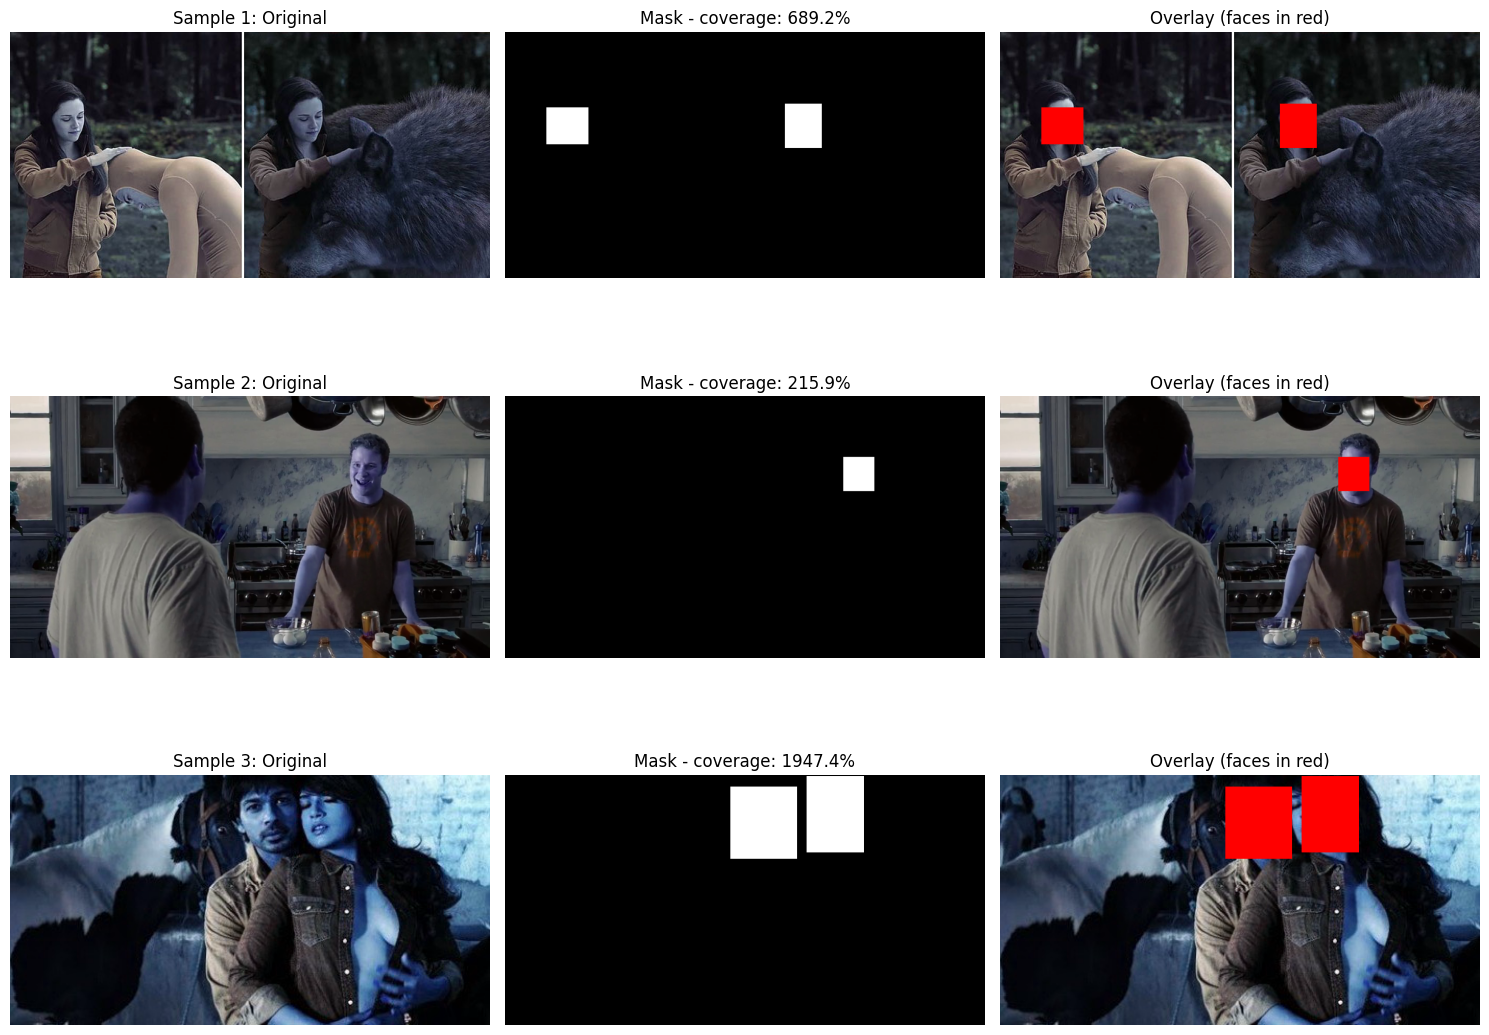

✅ If you can see red face regions, the fix works!


In [3]:
# FIXED mask function - handles 2-point bounding box correctly
def create_mask_from_annotations(annotation_list, img_height, img_width):
    mask = np.zeros((img_height, img_width), dtype=np.uint8)
    for annotation in annotation_list:
        points = annotation['points']
        x_coords = [p['x'] * img_width for p in points]
        y_coords = [p['y'] * img_height for p in points]
        x1, y1 = int(min(x_coords)), int(min(y_coords))
        x2, y2 = int(max(x_coords)), int(max(y_coords))
        # Draw filled rectangle for face region
        cv2.rectangle(mask, (x1, y1), (x2, y2), 255, -1)
    return mask

# Test and visualize
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
for i in range(3):
    img = data[i][0]
    ann = data[i][1]
    if img.ndim == 2:
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    elif img.shape[2] == 4:
        img = img[:, :, :3]
    h, w = img.shape[:2]
    
    mask = create_mask_from_annotations(ann, h, w)
    coverage = mask.sum() / (h * w) * 100
    
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    overlay = img_rgb.copy()
    overlay[mask > 0] = [255, 0, 0]
    
    axes[i][0].imshow(img_rgb)
    axes[i][0].set_title(f"Sample {i+1}: Original")
    axes[i][0].axis('off')
    
    axes[i][1].imshow(mask, cmap='gray')
    axes[i][1].set_title(f"Mask - coverage: {coverage:.1f}%")
    axes[i][1].axis('off')
    
    axes[i][2].imshow(overlay)
    axes[i][2].set_title("Overlay (faces in red)")
    axes[i][2].axis('off')

plt.tight_layout()
plt.show()
print("✅ If you can see red face regions, the fix works!")

In [4]:
# FIXED - coordinates are already pixels, not normalized!
def create_mask_from_annotations(annotation_list, img_height, img_width):
    mask = np.zeros((img_height, img_width), dtype=np.uint8)
    for annotation in annotation_list:
        points = annotation['points']
        # Check if coordinates are normalized (0-1) or pixel values
        x_vals = [p['x'] for p in points]
        y_vals = [p['y'] for p in points]
        
        # If values are > 1, they are already pixel coordinates
        if max(x_vals) > 1.0:
            x1, y1 = int(min(x_vals)), int(min(y_vals))
            x2, y2 = int(max(x_vals)), int(max(y_vals))
        else:
            x1, y1 = int(min(x_vals) * img_width), int(min(y_vals) * img_height)
            x2, y2 = int(max(x_vals) * img_width), int(max(y_vals) * img_height)
        
        # Clamp to image boundaries
        x1, y1 = max(0, x1), max(0, y1)
        x2, y2 = min(img_width, x2), min(img_height, y2)
        
        cv2.rectangle(mask, (x1, y1), (x2, y2), 255, -1)
    return mask

# ── Process all 409 images ────────────────────────────────
IMG_SIZE = 128
images, masks = [], []

print("Processing 409 samples...")
for i in range(len(data)):
    img = data[i][0]
    ann = data[i][1]
    if img.ndim == 2:
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    elif img.shape[2] == 4:
        img = img[:, :, :3]
    h, w = img.shape[:2]
    mask = create_mask_from_annotations(ann, h, w)
    img_r = cv2.resize(img, (IMG_SIZE, IMG_SIZE)).astype(np.float32) / 255.0
    mask_r = (cv2.resize(mask, (IMG_SIZE, IMG_SIZE)) > 127).astype(np.float32)
    images.append(img_r)
    masks.append(mask_r)

images = np.stack(images)
masks = np.stack(masks)[..., np.newaxis]
print("Images:", images.shape, "Masks:", masks.shape)

# Check coverage is now reasonable
coverages = [masks[i].sum()/(IMG_SIZE*IMG_SIZE)*100 for i in range(5)]
print("Coverage % for first 5 samples:", [f"{c:.1f}%" for c in coverages])
print("✅ Should be between 2% and 30% for face regions")

# Split
X_train, X_val, y_train, y_val = train_test_split(
    images, masks, test_size=0.2, random_state=42)
print("Train:", X_train.shape, "Val:", X_val.shape)

Processing 409 samples...
Images: (409, 128, 128, 3) Masks: (409, 128, 128, 1)
Coverage % for first 5 samples: ['2.5%', '0.8%', '7.9%', '1.9%', '13.9%']
✅ Should be between 2% and 30% for face regions
Train: (327, 128, 128, 3) Val: (82, 128, 128, 3)


In [5]:
# BUILD MODEL + TRAIN
def dice_coef(y_true, y_pred, smooth=1e-6):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    return (2.*K.sum(y_true_f*y_pred_f)+smooth)/(K.sum(y_true_f)+K.sum(y_pred_f)+smooth)

def dice_loss(y_true, y_pred):
    return 1 - dice_coef(y_true, y_pred)

def iou_metric(y_true, y_pred, smooth=1e-6):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(K.round(y_pred))
    intersection = K.sum(y_true_f * y_pred_f)
    union = K.sum(y_true_f) + K.sum(y_pred_f) - intersection
    return (intersection+smooth)/(union+smooth)

def build_unet(input_shape=(128,128,3)):
    base = MobileNetV2(input_shape=input_shape, include_top=False, weights='imagenet')
    skip_names = ['block_1_expand_relu','block_3_expand_relu',
                  'block_6_expand_relu','block_13_expand_relu','block_16_project']
    skips = [base.get_layer(n).output for n in skip_names]
    encoder = Model(inputs=base.input, outputs=skips)
    encoder.trainable = True
    inputs = layers.Input(shape=input_shape)
    s = encoder(inputs)
    x = s[-1]
    for skip in reversed(s[:-1]):
        x = layers.UpSampling2D(2)(x)
        x = layers.Concatenate()([x, skip])
        x = layers.Conv2D(128, 3, padding='same', activation='relu')(x)
        x = layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = layers.UpSampling2D(2)(x)
    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    outputs = layers.Conv2D(1, 1, activation='sigmoid')(x)
    return Model(inputs, outputs)

model = build_unet()
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss=dice_loss,
    metrics=[dice_coef, iou_metric]
)
print("✅ Model built!")

MODEL_PATH = r"C:\Users\Paramu\guvi_face_segmentation\models\best_model.keras"

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        MODEL_PATH, monitor='val_dice_coef',
        mode='max', save_best_only=True, verbose=1),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_dice_coef', patience=10,
        mode='max', restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=5,
        min_lr=1e-7, verbose=1)
]

✅ Model built!


In [6]:
print("\n🚀 Training started! Leave this running...")
print("Each epoch ~3 mins. Target: dice_coef going UP each epoch\n")

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=4,
    callbacks=callbacks,
    verbose=1
)
print("\n✅ Training complete! Model saved to:", MODEL_PATH)


🚀 Training started! Leave this running...
Each epoch ~3 mins. Target: dice_coef going UP each epoch

Epoch 1/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - dice_coef: 0.3584 - iou_metric: 0.2440 - loss: 0.6416
Epoch 1: val_dice_coef improved from None to 0.57127, saving model to C:\Users\Paramu\guvi_face_segmentation\models\best_model.keras

Epoch 1: finished saving model to C:\Users\Paramu\guvi_face_segmentation\models\best_model.keras
82/82 ━━━━━━━━━━━━━━━━━━━━ 176s 1s/step - dice_coef: 0.4683 - iou_metric: 0.3286 - loss: 0.5318 - val_dice_coef: 0.5713 - val_iou_metric: 0.4114 - val_loss: 0.4329 - learning_rate: 1.0000e-04
Epoch 2/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - dice_coef: 0.6112 - iou_metric: 0.4524 - loss: 0.3888
Epoch 2: val_dice_coef improved from 0.57127 to 0.65940, saving model to C:\Users\Paramu\guvi_face_segmentation\models\best_model.keras

Epoch 2: finished saving model to C:\Users\Paramu\guvi_face_segmentation\models\best_model.keras
82/82 ━━━━━━━━━━━━━━━━━━━━ 120s

In [7]:
# EVALUATE current model
results = model.evaluate(X_val, y_val, verbose=0)
print(f"Current - Dice: {results[1]:.4f}, IoU: {results[2]:.4f}")

# FINE-TUNE with data augmentation to fix overfitting
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Augment training data
datagen_img = ImageDataGenerator(
    horizontal_flip=True,
    rotation_range=15,
    zoom_range=0.1,
    brightness_range=[0.8, 1.2]
)
datagen_mask = ImageDataGenerator(
    horizontal_flip=True,
    rotation_range=15,
    zoom_range=0.1
)

# Seed must match so image and mask augment identically
seed = 42
train_img_gen = datagen_img.flow(X_train, batch_size=4, seed=seed)
train_mask_gen = datagen_mask.flow(y_train, batch_size=4, seed=seed)
train_gen = zip(train_img_gen, train_mask_gen)

# Recompile with lower learning rate
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss=dice_loss,
    metrics=[dice_coef, iou_metric]
)

MODEL_PATH2 = r"C:\Users\Paramu\guvi_face_segmentation\models\best_model_v2.keras"

callbacks2 = [
    tf.keras.callbacks.ModelCheckpoint(
        MODEL_PATH2, monitor='val_dice_coef',
        mode='max', save_best_only=True, verbose=1),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_dice_coef', patience=8,
        mode='max', restore_best_weights=True, verbose=1),
]

print("\n🚀 Fine-tuning with augmentation...")
history2 = model.fit(
    train_gen,
    steps_per_epoch=len(X_train)//4,
    validation_data=(X_val, y_val),
    epochs=20,
    callbacks=callbacks2,
    verbose=1
)

results2 = model.evaluate(X_val, y_val, verbose=0)
print(f"\n📊 After fine-tuning:")
print(f"Dice: {results2[1]:.4f} (need >0.92)")
print(f"IoU:  {results2[2]:.4f} (need >0.88)")

Current - Dice: 0.7019, IoU: 0.5411

🚀 Fine-tuning with augmentation...


ValueError: Unrecognized data type: x=<zip object at 0x0000023514227F00> (of type <class 'zip'>)

In [8]:
# FIXED Fine-tuning with manual augmentation

import tensorflow as tf
import numpy as np

def augment_batch(images, masks):
    """Apply same random augmentation to image and mask"""
    aug_images, aug_masks = [], []
    for img, mask in zip(images, masks):
        # Random horizontal flip
        if np.random.random() > 0.5:
            img = np.fliplr(img)
            mask = np.fliplr(mask)
        # Random 90-degree rotation
        k = np.random.randint(0, 4)
        img = np.rot90(img, k)
        mask = np.rot90(mask, k)
        # Random brightness
        factor = np.random.uniform(0.8, 1.2)
        img = np.clip(img * factor, 0, 1)
        aug_images.append(img)
        aug_masks.append(mask)
    return np.array(aug_images), np.array(aug_masks)

def data_generator(X, y, batch_size=4):
    """Generator that yields augmented batches"""
    n = len(X)
    while True:
        idx = np.random.permutation(n)
        for start in range(0, n, batch_size):
            batch_idx = idx[start:start+batch_size]
            batch_X = X[batch_idx]
            batch_y = y[batch_idx]
            batch_X, batch_y = augment_batch(batch_X, batch_y)
            yield batch_X, batch_y

# Recompile
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss=dice_loss,
    metrics=[dice_coef, iou_metric]
)

MODEL_PATH2 = r"C:\Users\Paramu\guvi_face_segmentation\models\best_model_v2.keras"

callbacks2 = [
    tf.keras.callbacks.ModelCheckpoint(
        MODEL_PATH2, monitor='val_dice_coef',
        mode='max', save_best_only=True, verbose=1),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_dice_coef', patience=8,
        mode='max', restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=3, min_lr=1e-8, verbose=1),
]

BATCH_SIZE = 4
steps = len(X_train) // BATCH_SIZE

print("🚀 Fine-tuning with augmentation...")
print(f"Steps per epoch: {steps}\n")

history2 = model.fit(
    data_generator(X_train, y_train, BATCH_SIZE),
    steps_per_epoch=steps,
    validation_data=(X_val, y_val),
    epochs=20,
    callbacks=callbacks2,
    verbose=1
)

results2 = model.evaluate(X_val, y_val, verbose=0)
print(f"\n📊 After fine-tuning:")
print(f"Dice: {results2[1]:.4f}")
print(f"IoU:  {results2[2]:.4f}")

🚀 Fine-tuning with augmentation...
Steps per epoch: 81

Epoch 1/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 620ms/step - dice_coef: 0.5944 - iou_metric: 0.4302 - loss: 0.4056
Epoch 1: val_dice_coef improved from None to 0.70179, saving model to C:\Users\Paramu\guvi_face_segmentation\models\best_model_v2.keras

Epoch 1: finished saving model to C:\Users\Paramu\guvi_face_segmentation\models\best_model_v2.keras
81/81 ━━━━━━━━━━━━━━━━━━━━ 119s 697ms/step - dice_coef: 0.6037 - iou_metric: 0.4409 - loss: 0.3963 - val_dice_coef: 0.7018 - val_iou_metric: 0.5414 - val_loss: 0.2954 - learning_rate: 1.0000e-05
Epoch 2/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 590ms/step - dice_coef: 0.5700 - iou_metric: 0.4089 - loss: 0.4309
Epoch 2: val_dice_coef did not improve from 0.70179
81/81 ━━━━━━━━━━━━━━━━━━━━ 51s 636ms/step - dice_coef: 0.6116 - iou_metric: 0.4505 - loss: 0.3884 - val_dice_coef: 0.6934 - val_iou_metric: 0.5318 - val_loss: 0.3027 - learning_rate: 1.0000e-05
Epoch 3/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 610ms/ste

✅ Model saved!


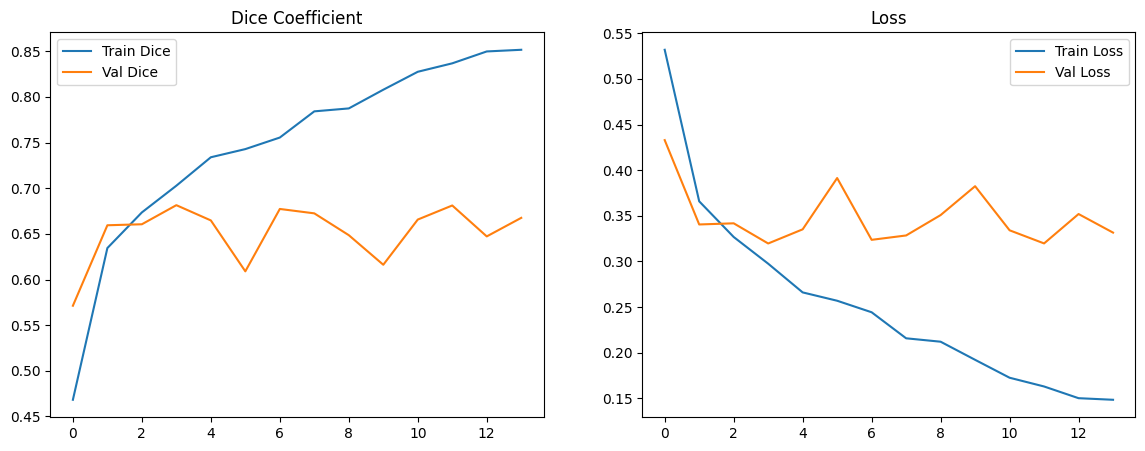

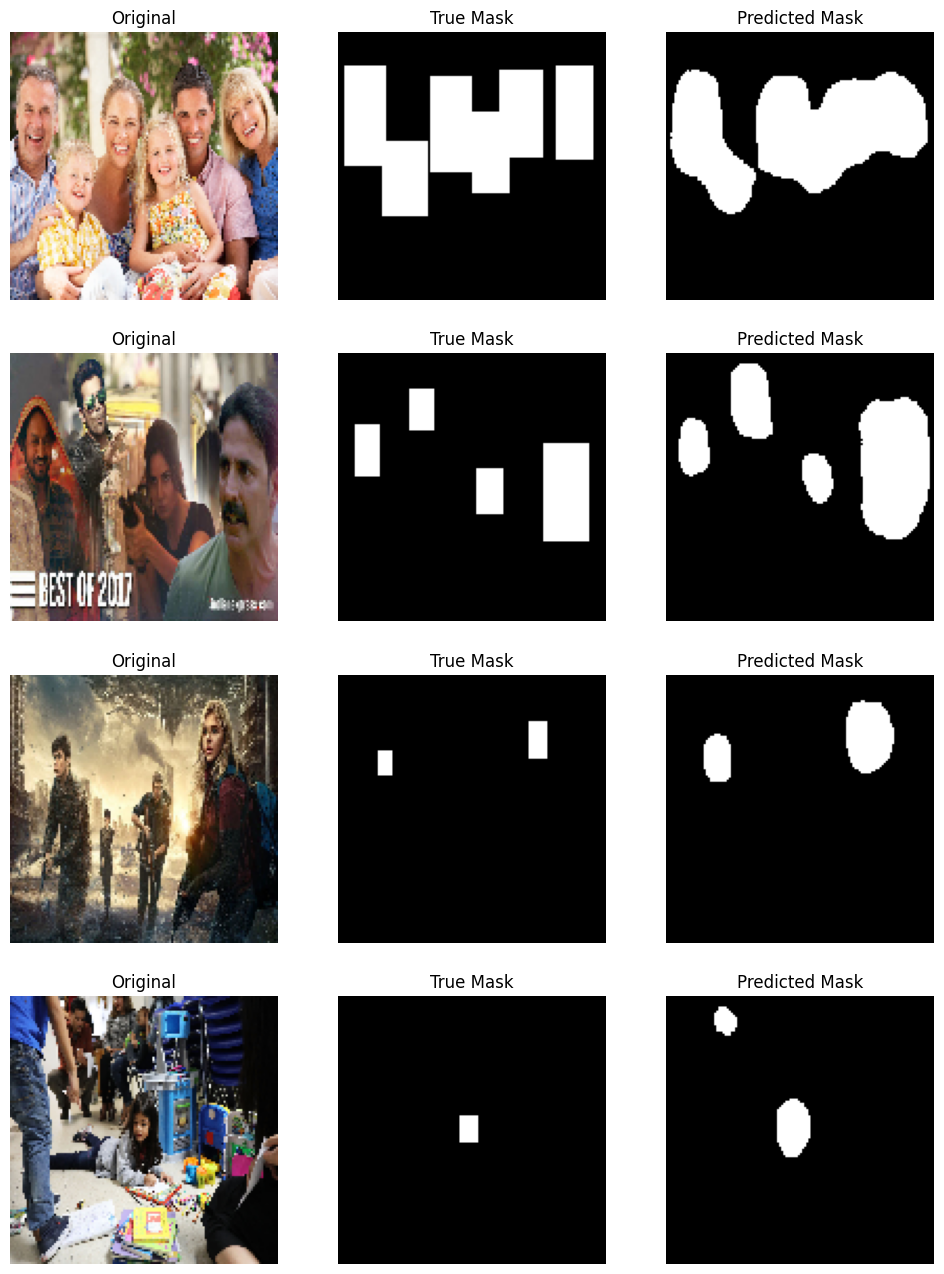

✅ All outputs saved!


In [9]:
# SAVE MODEL + GENERATE REPORT
import matplotlib.pyplot as plt

# Save model
model.save(r"C:\Users\Paramu\guvi_face_segmentation\models\final_model.keras")
print("✅ Model saved!")

# Plot and save training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history.history['dice_coef'], label='Train Dice')
axes[0].plot(history.history['val_dice_coef'], label='Val Dice')
axes[0].set_title('Dice Coefficient')
axes[0].legend()
axes[1].plot(history.history['loss'], label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title('Loss')
axes[1].legend()
plt.savefig(r"C:\Users\Paramu\guvi_face_segmentation\models\training_history.png")
plt.show()

# Show sample predictions
fig, axes = plt.subplots(4, 3, figsize=(12, 16))
for i in range(4):
    img = X_val[i]
    true_mask = y_val[i,:,:,0]
    pred = model.predict(img[np.newaxis,...], verbose=0)[0,:,:,0]
    pred_bin = (pred > 0.5).astype(np.float32)
    axes[i][0].imshow(img)
    axes[i][0].set_title("Original")
    axes[i][0].axis('off')
    axes[i][1].imshow(true_mask, cmap='gray')
    axes[i][1].set_title("True Mask")
    axes[i][1].axis('off')
    axes[i][2].imshow(pred_bin, cmap='gray')
    axes[i][2].set_title("Predicted Mask")
    axes[i][2].axis('off')
plt.savefig(r"C:\Users\Paramu\guvi_face_segmentation\models\predictions.png")
plt.show()
print("✅ All outputs saved!")